## Fine-Tuning & Profiling Transformers

## **Learning Objectives**

By completing this assignment, students will be able to:

1.   Implement fine-tuning logic once and reuse it for **LLMs and ViTs**
2.   Compare **parameter efficiency, convergence, and compute cost** across modalities
3.   Profile **memory, time, and trainable parameters**
4.   Develop intuition for **when fine-tuning helps vs hurts**

## **Models & Tasks**


```
| Modality | Model                         | Task                             |
| -------- | ----------------------------- | -------------------------------- |
| Text     | `distilbert-base-uncased`     | Sentiment / Topic Classification |
| Vision   | `google/vit-base-patch16-224` | CIFAR-10 Classification          |

```
NOTE: Please **DON'T** use HuggingFace Trainer or End-to-end copy and paste tutorials


In [3]:
from transformers import AutoModelForSequenceClassification
from transformers import ViTForImageClassification

In [4]:
# Utilities shared by BOTH LLM and ViT fine-tuning

def freeze_all(model):
    """
    Set requires_grad = False for all parameters in the model.

    Why: this is the clean baseline for "feature extractor" style fine-tuning.
    After calling this, you selectively re-enable gradients for the layers you want to train.
    """
    for p in model.parameters():
        p.requires_grad = False


def _get_transformer_blocks(model):
    """
    Return (blocks, kind) where blocks is an indexable list/ModuleList of transformer blocks.

    Supported (common HF classes):
      - DistilBERT sequence classification: model.distilbert.transformer.layer
      - BERT/RoBERTa/DeBERTa-like: model.<base>.encoder.layer
      - ViT image classification: model.vit.encoder.layer
    """
    # --- ViT ---
    if hasattr(model, "vit") and hasattr(model.vit, "encoder") and hasattr(model.vit.encoder, "layer"):
        return model.vit.encoder.layer, "vit"

    # --- DistilBERT ---
    if hasattr(model, "distilbert") and hasattr(model.distilbert, "transformer") and hasattr(model.distilbert.transformer, "layer"):
        return model.distilbert.transformer.layer, "distilbert"

    # --- Generic encoder.layer under a base model prefix (bert/roberta/deberta/etc.) ---
    for attr in ["bert", "roberta", "deberta", "deberta_v2", "electra", "albert", "xlnet"]:
        if hasattr(model, attr):
            base = getattr(model, attr)
            if hasattr(base, "encoder") and hasattr(base.encoder, "layer"):
                return base.encoder.layer, attr

    # Fallback: some models expose base_model with encoder.layer
    if hasattr(model, "base_model") and hasattr(model.base_model, "encoder") and hasattr(model.base_model.encoder, "layer"):
        return model.base_model.encoder.layer, "base_model"

    raise ValueError("Could not locate transformer blocks for this model architecture.")


def unfreeze_last_n_layers(model, n):
    """
    Unfreeze ONLY the last n transformer blocks.

    Works for:
      - DistilBERT-like models (model.distilbert.transformer.layer)
      - ViT models (model.vit.encoder.layer)
      - Many BERT-family models (model.bert.encoder.layer, model.roberta.encoder.layer, ...)
    """
    blocks, _ = _get_transformer_blocks(model)
    total = len(blocks)

    n = int(n)
    if n < 0:
        raise ValueError("n must be >= 0")
    if n > total:
        n = total

    # Unfreeze last n blocks
    for block in list(blocks)[total - n:]:
        for p in block.parameters():
            p.requires_grad = True

    # Also unfreeze the classifier head (common naming in HF heads)
    for head_name in ["classifier", "score", "classification_head", "pre_classifier"]:
        if hasattr(model, head_name):
            for p in getattr(model, head_name).parameters():
                p.requires_grad = True

    return total, n  # (total blocks, number unfrozen)


def count_trainable_params(model):
    """
    Return the total number of trainable parameters.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## **Model Loaders**

In [5]:
# LLM
def load_llm(num_labels):
    return AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=num_labels
    )

In [15]:
# ViT
def load_vit(num_labels):
    return ViTForImageClassification.from_pretrained(
        "google/vit-base-patch16-224",
        num_labels=num_labels,
        ignore_mismatched_sizes=True
    )

## **Training Loop**

This is the training loop used for both LLM and ViT.

In [7]:
import time
import torch
import torch.nn.functional as F
from tqdm import tqdm

def _move_to_device(batch, device):
    """
    Move a batch (dict of tensors) to device.
    Dataloaders for HF models typically return dicts like:
      - LLM: {input_ids, attention_mask, labels, ...}
      - ViT: {pixel_values, labels}
    """
    out = {}
    for k, v in batch.items():
        if torch.is_tensor(v):
            out[k] = v.to(device)
        else:
            out[k] = v
    return out

def _accuracy_from_logits(logits, labels):
    preds = torch.argmax(logits, dim=-1)
    return (preds == labels).float().mean().item()

def train_epoch(model, dataloader, optimizer, device):
    """
    One epoch of training.

    Returns:
      avg_loss (float): mean loss across batches
      avg_acc  (float): mean accuracy across batches
    """
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    num_batches = 0

    for batch in tqdm(dataloader, desc="Train", leave=False):
        batch = _move_to_device(batch, device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(**batch)
        loss = outputs.loss

        # Safety fallback if loss isn't provided
        if loss is None:
            logits = outputs.logits
            loss = F.cross_entropy(logits, batch["labels"])

        loss.backward()
        optimizer.step()

        logits = outputs.logits
        total_loss += float(loss.detach().cpu().item())
        total_acc  += float(_accuracy_from_logits(logits, batch["labels"]))
        num_batches += 1

    return total_loss / max(1, num_batches), total_acc / max(1, num_batches)

@torch.no_grad()
def eval_epoch(model, dataloader, device):
    """
    One epoch of evaluation (no gradients).

    Returns:
      avg_loss (float): mean loss across batches
      avg_acc  (float): mean accuracy across batches
    """
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    num_batches = 0

    for batch in tqdm(dataloader, desc="Val", leave=False):
        batch = _move_to_device(batch, device)
        outputs = model(**batch)
        loss = outputs.loss

        if loss is None:
            logits = outputs.logits
            loss = F.cross_entropy(logits, batch["labels"])

        logits = outputs.logits
        total_loss += float(loss.detach().cpu().item())
        total_acc  += float(_accuracy_from_logits(logits, batch["labels"]))
        num_batches += 1

    return total_loss / max(1, num_batches), total_acc / max(1, num_batches)

def train(model, train_loader, val_loader, optimizer, scheduler, device, epochs=5, patience=2):
    """
    Full training loop with:
      - training loop + validation loop
      - scheduler step (if provided)
      - epoch logging
      - early stopping using patience (based on validation loss)
      - basic profiling (epoch time + peak GPU memory)

    Returns:
      best_state_dict (dict): state dict corresponding to best validation loss
      history (dict): lists of metrics across epochs
    """
    best_val = float("inf")
    best_state = None
    bad_epochs = 0

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
        "epoch_time_sec": [], "max_mem_mb": []
    }

    use_cuda = (device.type == "cuda")
    if use_cuda:
        torch.cuda.reset_peak_memory_stats()

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, device)
        val_loss, val_acc = eval_epoch(model, val_loader, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Scheduler handling:
        # - ReduceLROnPlateau expects a metric
        # - most others expect just step()
        if scheduler is not None:
            if scheduler.__class__.__name__ == "ReduceLROnPlateau":
                scheduler.step(val_loss)
            else:
                scheduler.step()

        t1 = time.time()
        history["epoch_time_sec"].append(t1 - t0)

        if use_cuda:
            history["max_mem_mb"].append(torch.cuda.max_memory_allocated() / (1024**2))
        else:
            history["max_mem_mb"].append(0.0)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | "
            f"time={history['epoch_time_sec'][-1]:.1f}s, mem={history['max_mem_mb'][-1]:.1f}MB"
        )

        # Early stopping check (based on val_loss)
        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping: no improvement for {patience} epochs. Best val_loss={best_val:.4f}")
                break

    # Restore best weights (optional, but good for submission)
    if best_state is not None:
        model.load_state_dict(best_state)

    return best_state, history


## **Experiments & Plots**

The cells below will:
- Train each modality under **two different hyperparameter settings**
- Record loss/accuracy/time/memory
- Plot training curves
- Provide a short comparison/analysis

### Setup: Reproducibility and Device Configuration

This cell initializes random seeds for reproducibility and selects the computation device (CPU or GPU).

In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


### Visualization Utilities

This cell defines plotting helpers to visualize training and validation loss and accuracy across epochs,
similar to HW1.

In [9]:
def plot_histories(histories, title):
    # Loss
    plt.figure()
    for label, h in histories.items():
        plt.plot(h["train_loss"], label=f"{label} train")
        plt.plot(h["val_loss"],   label=f"{label} val")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # Accuracy
    plt.figure()
    for label, h in histories.items():
        plt.plot(h["train_acc"], label=f"{label} train")
        plt.plot(h["val_acc"],   label=f"{label} val")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

### Text Dataset Preparation (IMDB)

This cell loads the IMDB sentiment dataset and tokenizes it using the DistilBERT tokenizer.
It also creates a DataLoader factory so batch size can change across hyperparameter settings.

In [10]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding
from torch.utils.data import DataLoader

TEXT_MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)

raw_text = load_dataset("imdb")

def tok_fn(ex):
    return tokenizer(ex["text"], truncation=True)

tok_text = raw_text.map(tok_fn, batched=True)
tok_text = tok_text.rename_column("label", "labels")
tok_text.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

text_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def make_text_loaders(batch_size=16):
    train_loader = DataLoader(tok_text["train"], batch_size=batch_size, shuffle=True, collate_fn=text_collator)
    val_loader   = DataLoader(tok_text["test"],  batch_size=batch_size, shuffle=False, collate_fn=text_collator)
    return train_loader, val_loader

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

### Vision Dataset Preparation (CIFAR-10)

This cell loads CIFAR-10 and preprocesses images using the ViT image processor.
It returns batches in the format expected by ViT: `{pixel_values, labels}`.

In [11]:
import torchvision
from torchvision.datasets import CIFAR10
from torch.utils.data import Dataset, DataLoader
from transformers import AutoImageProcessor

VIT_MODEL_NAME = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(VIT_MODEL_NAME)

class CIFAR10ForViT(Dataset):
    def __init__(self, root, train=True):
        self.ds = CIFAR10(root=root, train=train, download=True)

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img, label = self.ds[idx]
        enc = processor(images=img, return_tensors="pt")
        pixel_values = enc["pixel_values"].squeeze(0)  # (3, 224, 224)
        return {"pixel_values": pixel_values, "labels": torch.tensor(label, dtype=torch.long)}

def make_cifar10_loaders(batch_size=64, root="./data"):
    train_ds = CIFAR10ForViT(root=root, train=True)
    val_ds   = CIFAR10ForViT(root=root, train=False)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, val_loader

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


### Hyperparameter Experiments: DistilBERT (Text)

This cell runs **two** hyperparameter configurations (learning rate + batch size) for the text model.
We keep the fine-tuning strategy constant so the comparison isolates hyperparameter effects.

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[Text lr2e-5_bs16] trainable params: 14767874


Epoch 01/5 | train_loss=0.2704, train_acc=0.8867 | val_loss=0.2021, val_acc=0.9199 | time=222.8s, mem=1373.0MB


...

Epoch 01/5 | train_loss=0.2650, train_acc=0.8922 | val_loss=0.2048, val_acc=0.9174 | time=212.3s, mem=2349.2MB


Epoch 02/5 | train_loss=0.1959, train_acc=0.9246 | val_loss=0.1960, val_acc=0.9241 | time=212.5s, mem=2349.2MB


Epoch 03/5 | train_loss=0.1587, train_acc=0.9401 | val_loss=0.1961, val_acc=0.9263 | time=212.3s, mem=2349.2MB


Epoch 04/5 | train_loss=0.1181, train_acc=0.9573 | val_loss=0.1897, val_acc=0.9301 | time=212.4s, mem=2349.2MB


Epoch 05/5 | train_loss=0.0832, train_acc=0.9697 | val_loss=0.2184, val_acc=0.9274 | time=212.6s, mem=2349.2MB


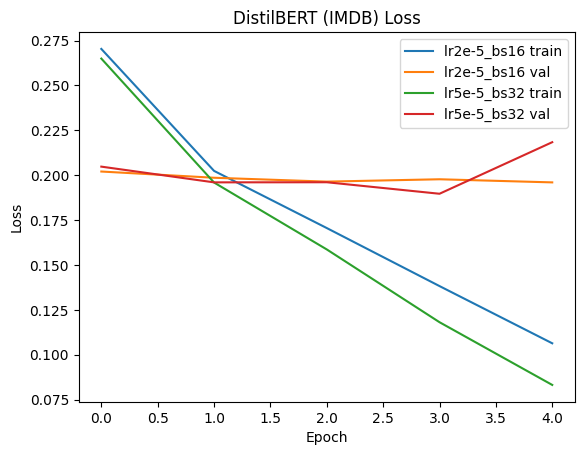

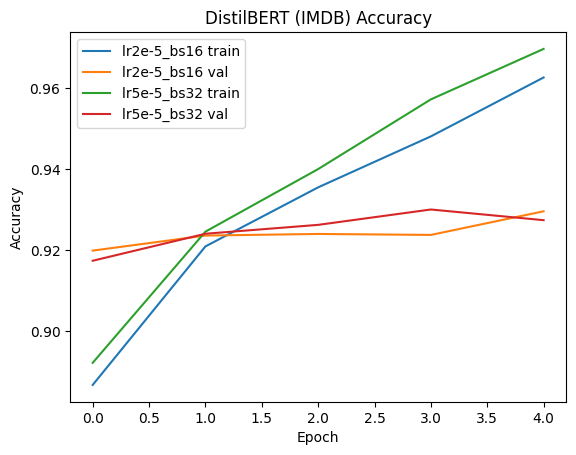

In [12]:
from torch.optim import AdamW

text_results = {}

text_configs = [
    {"lr": 2e-5, "bs": 16, "label": "lr2e-5_bs16"},
    {"lr": 5e-5, "bs": 32, "label": "lr5e-5_bs32"},
]

for cfg in text_configs:
    train_loader, val_loader = make_text_loaders(batch_size=cfg["bs"])

    model = load_llm(num_labels=2).to(device)

    # Fine-tuning setting (keep constant across hyperparam runs)
    freeze_all(model)
    unfreeze_last_n_layers(model, 2)

    print(f"[Text {cfg['label']}] trainable params:", count_trainable_params(model))

    optimizer = AdamW([p for p in model.parameters() if p.requires_grad], lr=cfg["lr"])
    scheduler = None

    _, hist = train(model, train_loader, val_loader, optimizer, scheduler, device, epochs=5, patience=2)
    text_results[cfg["label"]] = hist

plot_histories(text_results, "DistilBERT (IMDB)")

Text (DistilBERT, IMDB):
Two hyperparameter configurations were evaluated: (1) learning rate
2
×
10
−
5
2×10
−5
 with batch size 16, and (2) learning rate
5
×
10
−
5
5×10
−5
 with batch size 32. Both settings converged quickly and achieved similar validation accuracy near 0.93. The lower learning rate with smaller batch size produced more stable validation behavior, with validation loss decreasing steadily from 0.2021 to 0.1960 and validation accuracy improving to 0.9296 by epoch 5. In contrast, the higher learning rate with larger batch size reached its best validation accuracy slightly earlier (0.9301 at epoch 4) and attained a lower minimum validation loss (0.1897 at epoch 4), but validation loss increased sharply to 0.2184 by epoch 5, indicating mild overfitting or optimization instability. In terms of compute cost, batch size 32 reduced epoch time slightly (~212s vs ~222s) but increased peak GPU memory substantially (~2349MB vs ~1373MB). Overall, the higher learning rate and larger batch accelerated early convergence but reduced stability, while the smaller learning rate provided smoother generalization.

### Hyperparameter Experiments: ViT (Vision)

This cell runs **two** hyperparameter configurations for the vision model and plots training curves.

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


[ViT lr5e-5_bs64] trainable params: 14183434


Epoch 01/5 | train_loss=0.1862, train_acc=0.9566 | val_loss=0.0758, val_acc=0.9762 | time=176.7s, mem=1941.8MB


Epoch 02/5 | train_loss=0.0480, train_acc=0.9849 | val_loss=0.0707, val_acc=0.9781 | time=176.3s, mem=1942.0MB


...

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


[ViT lr1e-4_bs128] trainable params: 14183434


Epoch 01/5 | train_loss=0.1705, train_acc=0.9572 | val_loss=0.0729, val_acc=0.9752 | time=172.6s, mem=3387.3MB


Epoch 02/5 | train_loss=0.0419, train_acc=0.9875 | val_loss=0.0733, val_acc=0.9776 | time=172.5s, mem=3387.3MB


Epoch 03/5 | train_loss=0.0171, train_acc=0.9958 | val_loss=0.0770, val_acc=0.9783 | time=172.8s, mem=3387.3MB
Early stopping: no improvement for 2 epochs. Best val_loss=0.0729


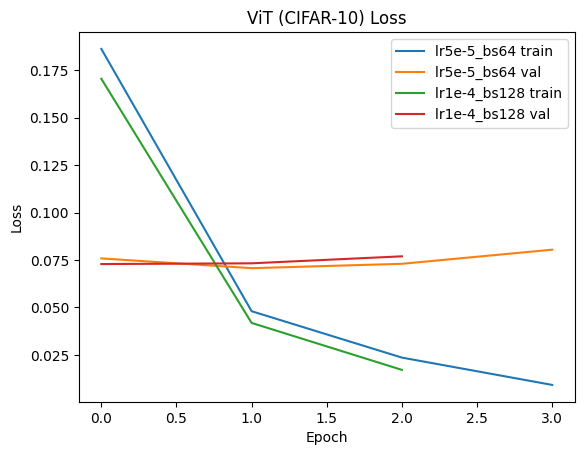

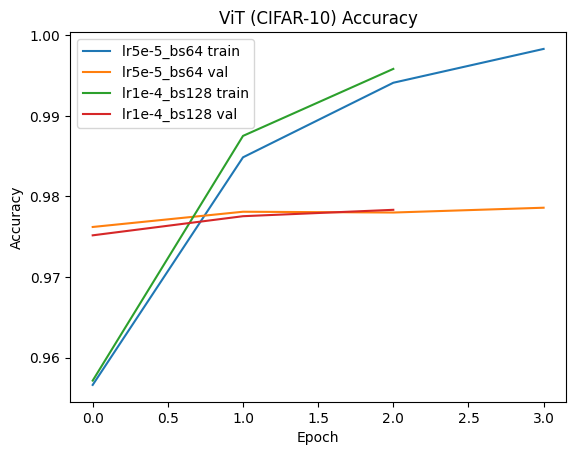

In [16]:
vit_results = {}

vit_configs = [
    {"lr": 5e-5, "bs": 64,  "label": "lr5e-5_bs64"},
    {"lr": 1e-4, "bs": 128, "label": "lr1e-4_bs128"},
]

for cfg in vit_configs:
    train_loader, val_loader = make_cifar10_loaders(batch_size=cfg["bs"], root="./data")

    model = load_vit(num_labels=10).to(device)

    freeze_all(model)
    unfreeze_last_n_layers(model, 2)

    print(f"[ViT {cfg['label']}] trainable params:", count_trainable_params(model))

    optimizer = AdamW([p for p in model.parameters() if p.requires_grad], lr=cfg["lr"])
    scheduler = None

    _, hist = train(model, train_loader, val_loader, optimizer, scheduler, device, epochs=5, patience=2)
    vit_results[cfg["label"]] = hist

plot_histories(vit_results, "ViT (CIFAR-10)")

### ViT Loss and Accuracy Analysis

The ViT model converged extremely quickly on CIFAR-10 under both hyperparameter configurations. Training loss decreased sharply within the first epoch and continued declining steadily, reaching near-zero values by epoch 3–4. Training accuracy exceeded 99%, indicating that the model has sufficient capacity to fit the dataset effectively.

Validation loss revealed clearer differences between configurations. The 5e-5 learning rate with batch size 64 achieved the lowest validation loss (approximately 0.0707) and maintained slightly more stable behavior before early stopping. In contrast, the higher learning rate (1e-4) with batch size 128 achieved strong validation accuracy but exhibited a gradual increase in validation loss after the first epoch, indicating earlier overfitting or reduced optimization stability.

Interestingly, validation accuracy remained high for both configurations (~97.8%), even as validation loss increased slightly. This suggests that while classification accuracy remained stable, the higher learning rate caused the model to become more overconfident in its predictions.

Overall, ViT demonstrated faster convergence and higher absolute accuracy compared to the text model, but also showed sensitivity to learning rate and earlier signs of overfitting.

In [17]:
def summarize(hist, label):
    avg_time = sum(hist["epoch_time_sec"]) / max(1, len(hist["epoch_time_sec"]))
    peak_mem = max(hist["max_mem_mb"]) if len(hist["max_mem_mb"]) else 0.0
    best_val_acc = max(hist["val_acc"]) if len(hist["val_acc"]) else float("nan")
    best_val_loss = min(hist["val_loss"]) if len(hist["val_loss"]) else float("nan")
    print(f"{label} | best_val_acc={best_val_acc:.4f}, best_val_loss={best_val_loss:.4f}, avg_epoch_time={avg_time:.1f}s, peak_mem={peak_mem:.1f}MB")

print("=== Text summaries ===")
for k, h in text_results.items():
    summarize(h, f"Text {k}")

print("\n=== ViT summaries ===")
for k, h in vit_results.items():
    summarize(h, f"ViT {k}")

=== Text summaries ===
Text lr2e-5_bs16 | best_val_acc=0.9296, best_val_loss=0.1960, avg_epoch_time=222.0s, peak_mem=1373.0MB
Text lr5e-5_bs32 | best_val_acc=0.9301, best_val_loss=0.1897, avg_epoch_time=212.4s, peak_mem=2349.2MB

=== ViT summaries ===
ViT lr5e-5_bs64 | best_val_acc=0.9786, best_val_loss=0.0707, avg_epoch_time=176.3s, peak_mem=1942.0MB
ViT lr1e-4_bs128 | best_val_acc=0.9783, best_val_loss=0.0729, avg_epoch_time=172.6s, peak_mem=3387.3MB
